In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

===============================================

CARGA Y LIMPIEZA DE DATOS

===============================================

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

# Convertir a DataFrame para verificar faltantes y duplicados
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

# i. Verificar valores faltantes y eliminar duplicados
print("Valores faltantes por columna:\n", df.isnull().sum())
df = df.drop_duplicates()
print(f"\nNúmero de muestras tras eliminar duplicados: {df.shape[0]} (original: {load_iris().data.shape[0]})")

# Separar X e y tras limpieza
X_clean = df[iris.feature_names].values
y_clean = df['target'].values

Valores faltantes por columna:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Número de muestras tras eliminar duplicados: 149 (original: 150)


===============================================

PREPROCESAMIENTO DE DATOS

===============================================

In [3]:
# i. Estandarizar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# ii. Dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

===============================================

ENTRENAMIENTO DEL MODELO DE ARBOLES DE DECISION

===============================================

In [4]:
# i. Profundidad máxima = 3
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# ii. Evaluación
y_pred = clf.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred)
accuracy_train = accuracy_score(y_train, clf.predict(X_train))

print(f"\nExactitud (Accuracy) en conjunto de prueba: {accuracy_test:.2f}")
print(f"Exactitud (Accuracy) en conjunto de entrenamiento: {accuracy_train:.2f}")

cm = confusion_matrix(y_test, y_pred)


Exactitud (Accuracy) en conjunto de prueba: 0.97
Exactitud (Accuracy) en conjunto de entrenamiento: 0.98


===============================================

VISUALIZACION DE RESULTADOS

===============================================

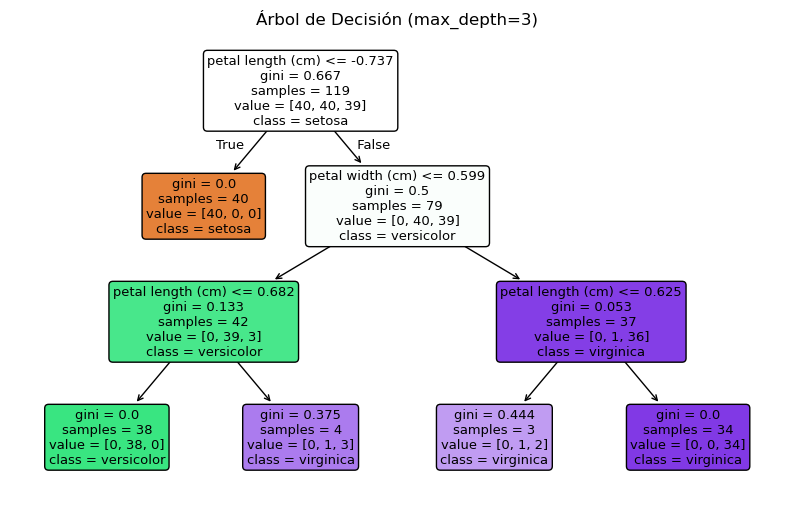

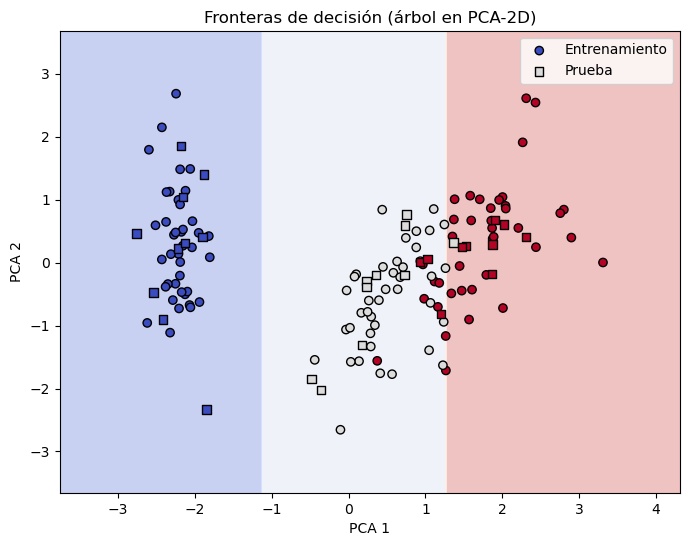

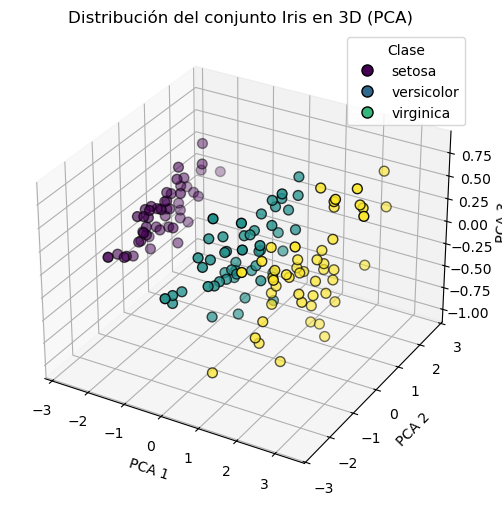

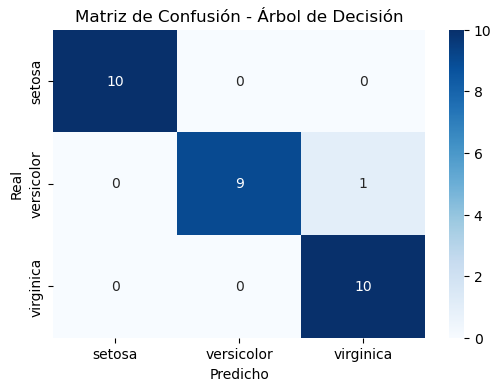

In [5]:
# i. Estructura del árbol con reglas de decisión
plt.figure(figsize=(10, 6))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Árbol de Decisión (max_depth=3)")
plt.show()

# ii. Fronteras de decisión (utilizamos PCA para reducir a 2 dimensiones para graficar)
pca_2d = PCA(n_components=2, random_state=42)
X_pca2d = pca_2d.fit_transform(X_scaled)

# Dividir los datos PCA en entreno/prueba para visualización
Xp_train, Xp_test, yp_train, yp_test = train_test_split(X_pca2d, y_clean, test_size=0.2, random_state=42, stratify=y_clean)

# Entrenar un árbol sobre las componentes PCA (solo para visualización de fronteras)
clf_pca = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_pca.fit(Xp_train, yp_train)

# Definir malla para el plano PCA
x_min, x_max = X_pca2d[:, 0].min() - 1, X_pca2d[:, 0].max() + 1
y_min, y_max = X_pca2d[:, 1].min() - 1, X_pca2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predecir en la malla
Z = clf_pca.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Puntos de entrenamiento
plt.scatter(Xp_train[:, 0], Xp_train[:, 1], c=yp_train, cmap='coolwarm', edgecolors='k', label='Entrenamiento', marker='o')
# Puntos de prueba
plt.scatter(Xp_test[:, 0], Xp_test[:, 1], c=yp_test, cmap='coolwarm', edgecolors='k', label='Prueba', marker='s')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Fronteras de decisión (árbol en PCA-2D)')
plt.legend()
plt.show()

# iii. Distribución espacial en 3 dimensiones (usar PCA para 3 componentes)
pca_3d = PCA(n_components=3, random_state=42)
X_pca3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca3d[:, 0], X_pca3d[:, 1], X_pca3d[:, 2],
    c=y_clean, cmap='viridis', edgecolors='k', s=50
)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('Distribución del conjunto Iris en 3D (PCA)')

# Crear leyenda de clases
legend_handles = []
for idx, target_name in enumerate(iris.target_names):
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w', label=target_name,
                   markerfacecolor=plt.cm.viridis(idx / len(iris.target_names)), markersize=8, markeredgecolor='k')
    )
ax.legend(handles=legend_handles, title='Clase')
plt.show()

# Mostrar la matriz de confusión en formato DataFrame
cm_df = pd.DataFrame(cm,
                     index=[f"True {name}" for name in iris.target_names],
                     columns=[f"Pred {name}" for name in iris.target_names])

# Visualizar matriz de confusión como heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()